   study_hours  attendance  previous_marks  pass
0            2          60              50     0
1            3          65              55     0
2            4          70              60     1
3            5          75              65     1
4            6          80              70     1
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     15 non-null     int64
 1   attendance      15 non-null     int64
 2   previous_marks  15 non-null     int64
 3   pass            15 non-null     int64
dtypes: int64(4)
memory usage: 612.0 bytes
None
study_hours       0
attendance        0
previous_marks    0
pass              0
dtype: int64


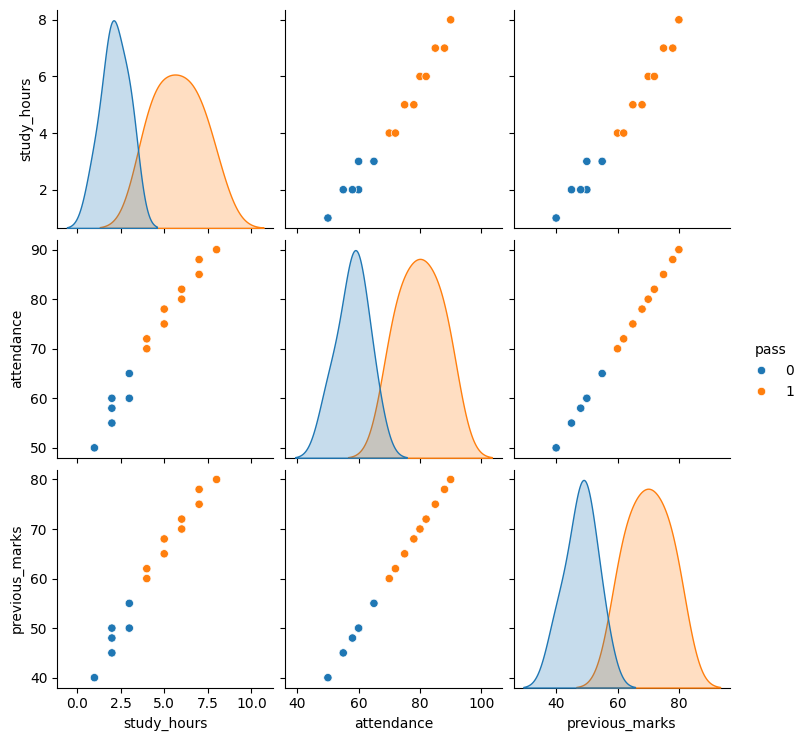

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 2]]
Prediction: [1]


C:\Users\Kiran Kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("student.csv")
print(df.head())

print(df.info())
print(df.isnull().sum())

sns.pairplot(df, hue='pass')
plt.show()

X = df[['study_hours', 'attendance', 'previous_marks']]
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

new_data = [[5, 75, 65]]
prediction = model.predict(new_data)
print("Prediction:", prediction)

In [3]:
new_data = pd.DataFrame([[5, 75, 65]], 
                        columns=['study_hours', 'attendance', 'previous_marks'])

prediction = model.predict(new_data)
print("Prediction:", prediction)

Prediction: [1]


   study_hours  attendance  previous_marks  pass
0            2          60              50     0
1            3          65              55     0
2            4          70              60     1
3            5          75              65     1
4            6          80              70     1
       study_hours  attendance  previous_marks       pass
count    15.000000   15.000000       15.000000  15.000000
mean      4.333333   71.200000       61.200000   0.600000
std       2.160247   12.700956       12.700956   0.507093
min       1.000000   50.000000       40.000000   0.000000
25%       2.500000   60.000000       50.000000   0.000000
50%       4.000000   72.000000       62.000000   1.000000
75%       6.000000   81.000000       71.000000   1.000000
max       8.000000   90.000000       80.000000   1.000000


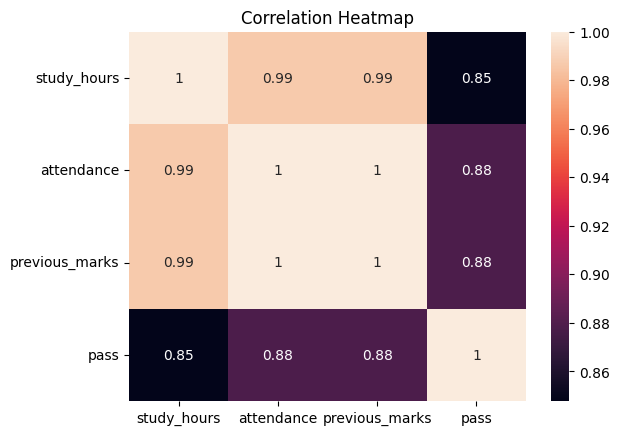

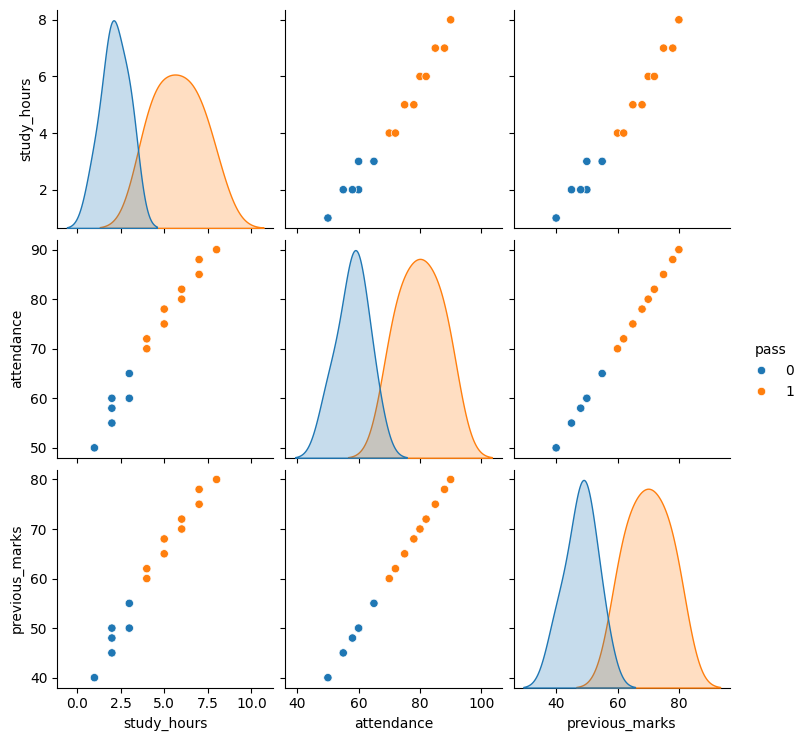

🔹 Logistic Regression Accuracy: 0.6666666666666666
🔹 Decision Tree Accuracy: 1.0

Confusion Matrix (Logistic Regression):
[[2 1]
 [0 0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3


Prediction (1=Pass, 0=Fail): [1]


C:\Users\Kiran Kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kiran Kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kiran Kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_cl

In [4]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load Dataset
df = pd.read_csv("student.csv")

# Step 3: Basic Info
print(df.head())
print(df.describe())

# Step 4: Visualization

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df, hue='pass')
plt.show()

# Step 5: Split Data
X = df[['study_hours', 'attendance', 'previous_marks']]
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 6: Models

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree (Better accuracy sometimes)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Step 7: Evaluation

print("🔹 Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("🔹 Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Step 8: Custom Prediction (FIXED)
new_data = pd.DataFrame([[5, 75, 65]], 
                        columns=['study_hours', 'attendance', 'previous_marks'])

prediction = lr.predict(new_data)
print("\nPrediction (1=Pass, 0=Fail):", prediction)

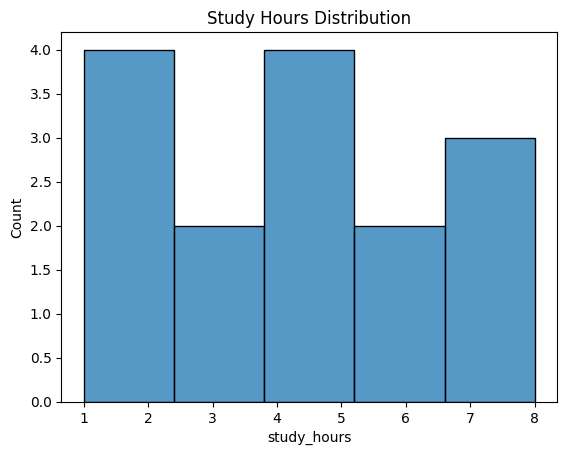

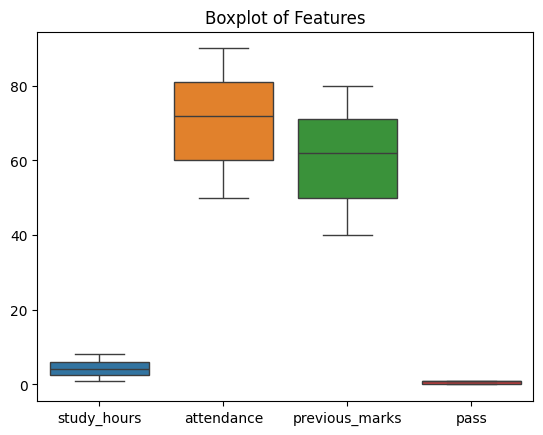

In [5]:
# Distribution plot
sns.histplot(df['study_hours'])
plt.title("Study Hours Distribution")
plt.show()

# Boxplot
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.show()

In [6]:
import joblib
joblib.dump(lr, "model.pkl")

['model.pkl']

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load data
df = pd.read_csv("student.csv")

# Features & target
X = df[['study_hours', 'attendance', 'previous_marks']]
y = df['pass']

# ✅ FIXED split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Models
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_pred))

# ✅ FIXED report
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred, zero_division=1))

# Prediction (correct format)
new_data = pd.DataFrame([[5, 75, 65]],
                        columns=['study_hours', 'attendance', 'previous_marks'])

print("\nPrediction:", lr.predict(new_data))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 2]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Prediction: [1]
